<a href="https://colab.research.google.com/github/Gokul-S777/ioe-ece5801/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Heart Rate Dataset
   Time  HeartRate
0     1         72
1     2         78
2     3         55
3     4         80
4     5         98
5     6        110
6     7         76
7     8         58
8     9        125
9    10         85

Heart Rate Status
   Time  HeartRate        Status
0     1         72        Normal
1     2         78        Normal
2     3         55   Low Anomaly
3     4         80        Normal
4     5         98        Normal
5     6        110  High Anomaly
6     7         76        Normal
7     8         58   Low Anomaly
8     9        125  High Anomaly
9    10         85        Normal


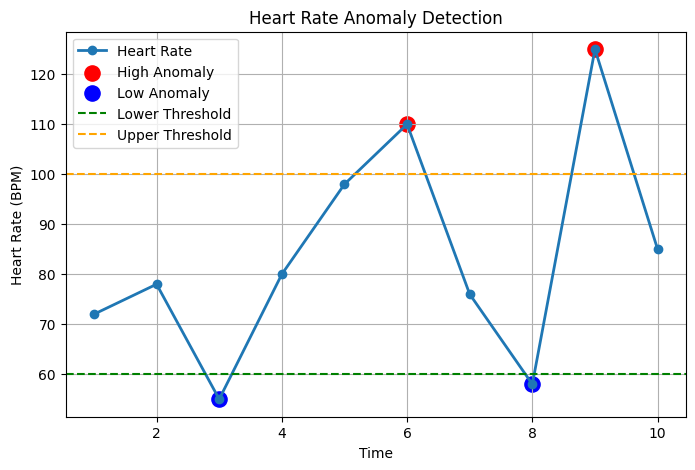


Normal Readings : 6
Low Anomalies   : 2
High Anomalies  : 2


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataset
data = {
    "Time": [1,2,3,4,5,6,7,8,9,10],
    "HeartRate": [72,78,55,80,98,110,76,58,125,85]
}

df = pd.DataFrame(data)

# Save CSV
df.to_csv("heart_rate_data.csv", index=False)

# Read CSV
df = pd.read_csv("heart_rate_data.csv")

print("Heart Rate Dataset")
print(df)

# Detect anomalies
def detect_status(hr):
    if hr < 60:
        return "Low Anomaly"
    elif hr > 100:
        return "High Anomaly"
    else:
        return "Normal"

df["Status"] = df["HeartRate"].apply(detect_status)

print("\nHeart Rate Status")
print(df)

# Plot Graph
plt.figure(figsize=(8,5))

# Normal Line
plt.plot(df["Time"], df["HeartRate"],
         marker='o',
         linewidth=2,
         label="Heart Rate")

# High anomalies
high = df[df["HeartRate"] > 100]
plt.scatter(high["Time"], high["HeartRate"],
            color='red',
            s=120,
            label="High Anomaly")

# Low anomalies
low = df[df["HeartRate"] < 60]
plt.scatter(low["Time"], low["HeartRate"],
            color='blue',
            s=120,
            label="Low Anomaly")

# Threshold lines
plt.axhline(y=60, color='green', linestyle='--', label='Lower Threshold')
plt.axhline(y=100, color='orange', linestyle='--', label='Upper Threshold')

plt.title("Heart Rate Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Heart Rate (BPM)")
plt.legend()
plt.grid(True)

plt.show()

print("\nNormal Readings :", len(df[df["Status"]=="Normal"]))
print("Low Anomalies   :", len(df[df["Status"]=="Low Anomaly"]))
print("High Anomalies  :", len(df[df["Status"]=="High Anomaly"]))